# Lesson 7: Smoothing and NPQ correction 🦠

### 🎯 Learning Objectives
In this lesson, we will learn how to apply smoothing and non-photochemical quenching (NPQ) correction to the chlorophyll-a data, which is a recommended post-processing for the chlorophyll-a data ([Schmechtig et al., 2023](https://archimer.ifremer.fr/doc/00243/35385/)).

### 🛠️ Prerequisites
Before starting this lesson, make sure that you have completed **Lesson 6**.

### ❓ How to Use This Notebook
* 📚 **Read** the tutorial text blocks carefully, as they provide the essential background information behind the code.
* ▶️ **Run** each code cell sequentially by clicking the cell and pressing `Shift + Enter`.
* 📝 **Exercise** your knowledge! At the end of this notebook, we provide active learning exercises where you will need to write or modify the code yourself.

### Ready? Let's Get Started!
---

## 📚 Tutorials

### Import libraries

▶️ **Run** the cell below to import relevant Python libraries for this lesson.

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy
from ipynb.fs.defs.lesson_4 import plot_2d_heatmap, filter_qc

### Load the float time series

▶️ **Run** the cell below to load the float time series downloaded in Lesson 3.

In [3]:
wmoid = 5906513

in_file = f"../floats/{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 
ds

<xarray.Dataset> Size: 19MB
Dimensions:                           (N_PROF: 123, N_PARAM: 9, N_CALIB: 1,
                                       N_LEVELS: 554)
Dimensions without coordinates: N_PROF, N_PARAM, N_CALIB, N_LEVELS
Data variables: (12/93)
    DATA_TYPE                         object 8B ...
    FORMAT_VERSION                    object 8B ...
    HANDBOOK_VERSION                  object 8B ...
    REFERENCE_DATE_TIME               object 8B ...
    DATE_CREATION                     object 8B ...
    DATE_UPDATE                       object 8B ...
    ...                                ...
    NITRATE                           (N_PROF, N_LEVELS) float32 273kB ...
    NITRATE_QC                        (N_PROF, N_LEVELS) object 545kB ...
    NITRATE_dPRES                     (N_PROF, N_LEVELS) float32 273kB ...
    NITRATE_ADJUSTED                  (N_PROF, N_LEVELS) float32 273kB ...
    NITRATE_ADJUSTED_QC               (N_PROF, N_LEVELS) object 545kB ...
    NITRATE_ADJUSTED_ERROR            (N_PROF, N_LEVELS) float32 273kB ...
Attributes:
    title:                Argo float vertical profile
    institution:          AOML
    source:               Argo float
    history:              2026-03-26T01:30:55Z creation (software version 1.2...
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  1.0
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile
    software_version:     1.20 (version 12.05.2025 for ARGO_simplified_profile)
    id:                   https://doi.org/10.17882/42182

### What is 

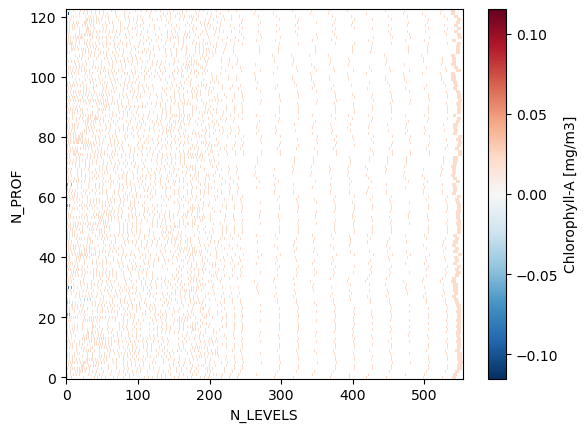

In [21]:
(ds["CHLA"]-ds["CHLA_ADJUSTED"]*2).plot()

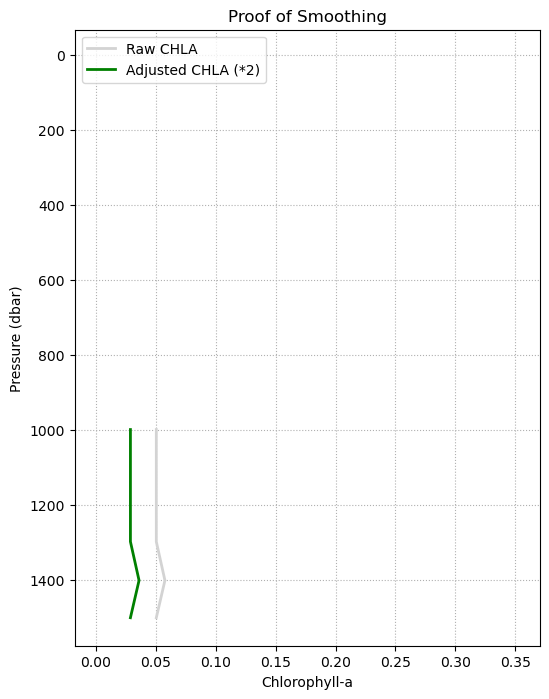

In [17]:
import matplotlib.pyplot as plt

# Pick a single profile to test (e.g., index 0)
prof_idx = 100

# Extract the data and drop NaNs for a clean plot
pres = ds['PRES'].isel(N_PROF=prof_idx)
raw_chla = ds['CHLA'].isel(N_PROF=prof_idx)
adj_chla = ds['CHLA_ADJUSTED'].isel(N_PROF=prof_idx)

plt.figure(figsize=(6, 8))

# 1. Plot the raw data (it will likely look spiky)
plt.plot(raw_chla, pres, label='Raw CHLA', color='lightgray', linewidth=2)

# 2. Plot the adjusted data, BUT multiply it by 2 to reverse the Roesler factor
# This aligns it with the raw data so we can see the smoothing!
plt.plot(adj_chla *2 , pres, label='Adjusted CHLA (*2)', color='green', linewidth=2)

plt.gca().invert_yaxis()
plt.ylabel('Pressure (dbar)')
plt.xlabel('Chlorophyll-a')
plt.title('Proof of Smoothing')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [6]:
calib_comment = ds['SCIENTIFIC_CALIB_COMMENT'].sel(N_PARAM='CHLA').values[0]
print(calib_comment)

KeyError: 'N_PARAM'

In [ ]:
filter_qc(ds,"CHLA_ADJUSTED",[1,2,5,8]

In [ ]:
try:
    good_ds,good_pres = ds_valid("CHLA_ADJUSTED",qc2keep)
    if good_ds.notnull().any(): # if finite values exit
        # vertical resolution
        pres_res = good_pres.diff(dim="N_LEVELS")
        pres_res_med = pres_res.median(dim="N_LEVELS")
    
        # create a dataset for smoothed profile
        ds_smooth = good_ds
    
        # 1. Create a boolean mask of where valid data currently exists
        original_mask = ds_smooth.notnull()
        
        # loop over profiles
        for i in range(pres_res_med.size):
            # window size logic (same as yours)
            if pres_res_med[i] >= 3:
                nsmooth = 5
            elif pres_res_med[i] <= 1:
                nsmooth = 11
            else:
                nsmooth = 7
            
            # 2. Apply Smoothing
            # You can keep min_periods=1 here if you want robust smoothing...
            smoothed_profile = ds_smooth[i,:].rolling(N_LEVELS=nsmooth, center=True, min_periods=1).median()
            
            # 3. ...BUT immediately re-apply the original mask
            # This forces any index that was originally NaN to stay NaN
            ds_smooth[i,:] = smoothed_profile.where(original_mask[i,:])
    
        # Plot
        fig = plt.figure()
        mmin,mmax = ds_smooth.min(),ds_smooth.max()
        ds_smooth.plot(x="N_PROF",cmap="plasma",vmin=mmin,vmax=mmax)
        plt.title("[SMOOTH] min: "+str(mmin.values)+", max: "+str(mmax.values))
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        plt.close(fig)
    else:
        print('NO GOOD DATA for CHLA_ADJUSTED')
except KeyError:
    print('NO DATA for CHLA_ADJUSTED')   

No variable named DOWNWELLING_PAR_ADJUSTED available


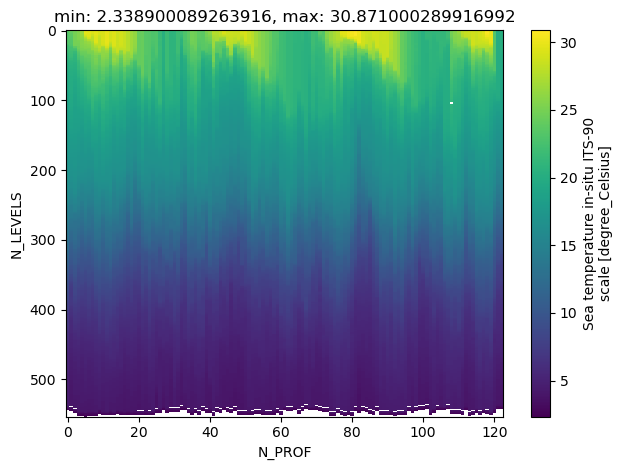

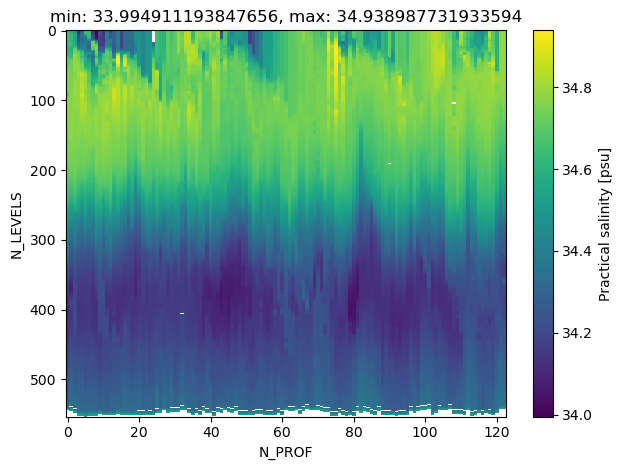

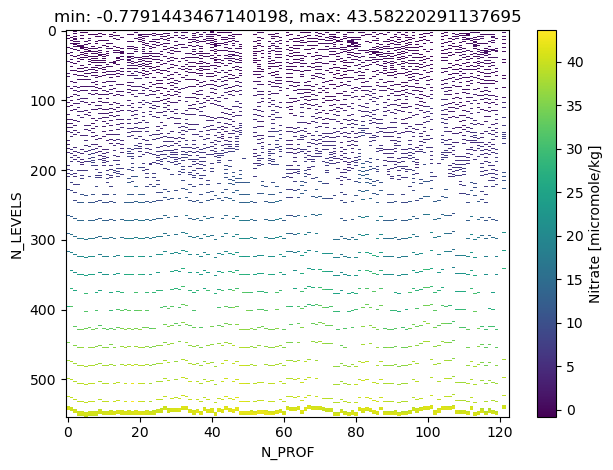

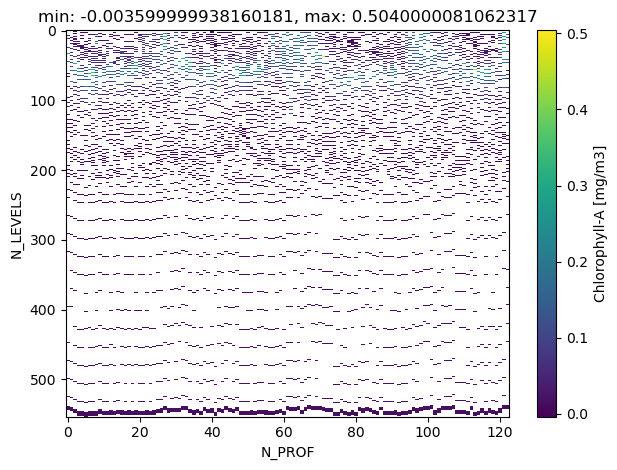

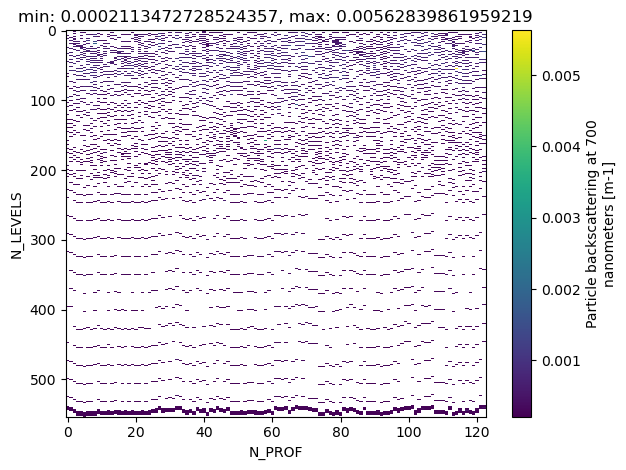

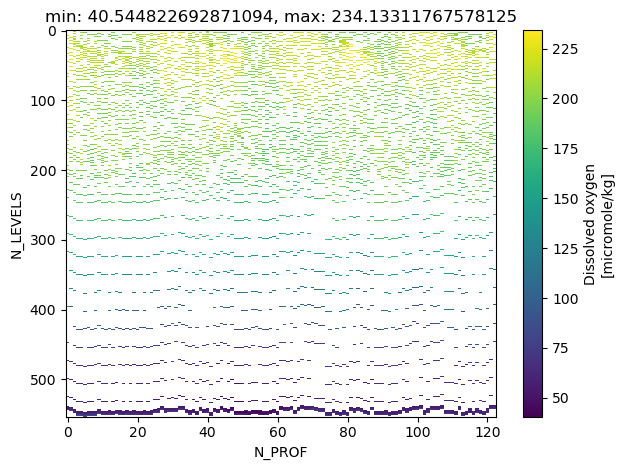

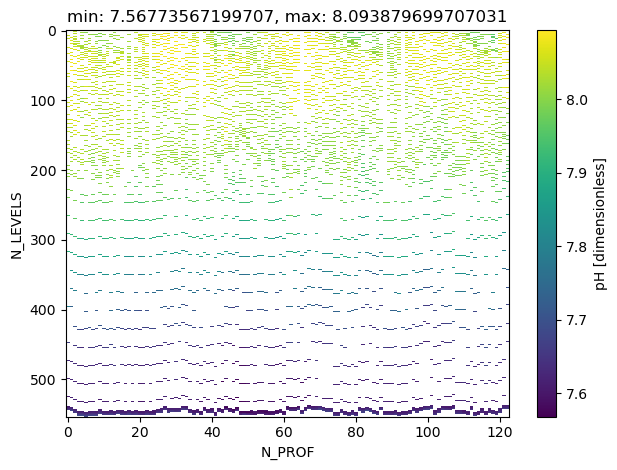

In [79]:
var_list = ['TEMP_ADJUSTED',
            'PSAL_ADJUSTED',
            'DOWNWELLING_PAR_ADJUSTED',
            'NITRATE_ADJUSTED',
            'CHLA_ADJUSTED',
            'BBP700_ADJUSTED',
            'DOXY_ADJUSTED',
            'PH_IN_SITU_TOTAL_ADJUSTED',
           ]

qc_list = [1,2,5,8]

plot_2d_heatmap(ds, var_list, qc_list)

### set up

5 m


In [38]:
def init_ds_interp(ds_ori, dep0, dep1, ddep):

    """
    This function creates a new xarray dataset for storing the interpolated arrays

    INPUT:
    * ds_ori: xarray dataset of the source
    * dep0: the shallowest depth defined for the interpolated array
    * dep1: the deepest depth defined for the interpolated array
    * ddep: the resolution resolution of the interpolated array (uniform)

    OUTPUT:
    * ds_int: xarray dataset for the interpolated arrays
    """
    
    # initialize the interpolated dataset
    ds_int = xr.Dataset()
    # longitude
    ds_int['LONGITUDE'] = xr.DataArray(
        ds_ori["LONGITUDE"].astype(np.float32),
        coords={'time': ('time', ds_ori["JULD"].values)},
        dims=['time'],attrs=ds_ori['LONGITUDE'].attrs
    )
    # latitude
    ds_int['LATITUDE'] = xr.DataArray(
        ds_ori["LATITUDE"].astype(np.float32),
        coords={'time': ('time', ds_ori["JULD"].values)},
        dims=['time'],attrs=ds_ori['LATITUDE'].attrs
    )

    # Create the depth array first so it's clean to pass in
    depth_values = np.arange(dep0, dep1 + ddep, ddep).astype(np.float32)

    # Finish the depth coordinate
    ds_int['depth'] = xr.DataArray(
        data=depth_values,
        coords={'depth': ('depth', depth_values)}, # Ties the dimension name to the values
        dims=['depth'],
        attrs=ds_ori['PRES_ADJUSTED'].attrs
    )
                                         
    return ds_int

In [71]:
int_dep0 = 5.0 # the shallowest depth (in dbar)
int_dep1 = 1000.0 # the deepest depth
int_ddep  = 5.0 # vertical resolution used for interpolation

ds_interp = init_ds_interp(ds, int_dep0, int_dep1, int_ddep)
ds_interp

<xarray.Dataset> Size: 3kB
Dimensions:    (time: 123, depth: 200)
Coordinates:
  * time       (time) datetime64[ns] 984B 2022-05-04T03:00:14.000322048 ... 2...
  * depth      (depth) float32 800B 5.0 10.0 15.0 20.0 ... 990.0 995.0 1e+03
Data variables:
    LONGITUDE  (time) float32 492B 136.6 136.8 136.7 136.8 ... 136.3 nan nan nan
    LATITUDE   (time) float32 492B 26.44 25.59 25.29 25.4 ... 29.91 nan nan nan

In [72]:
def interp_and_update(da_var_in, da_pres_in, ds_out):

    """
    This function interpolates the selected variable over the depth and adds the interpolated variable to the dataset.

    INPUT:
    * da_var_in: 2D xarray data array for the selected variable
    * da_pres_in: 2D xarray data array for the pressure
    * ds_out: xarray dataset for the interpolated data (generated via `init_ds_interp`)

    OUTPUT:
    * ds_out: the updated xarray dataset for the interpolated data
    """

    # Convert xarray to numpy arrays for data handling
    data_in = da_var_in.values
    
    # Initialize output array with NaNs
    data2d = np.full((ds_out['time'].size, ds_out['depth'].size), fill_value=np.nan)
    
    # loop over profiles
    for i in range(ds_out['time'].size):
        # 1. Clean the data: Filter out NaNs
        valid_mask = np.isfinite(da_pres_in[i,:]) & np.isfinite(da_var_in[i,:])
        curr_pres = da_pres_in[i,:][valid_mask].values
        curr_data = da_var_in[i,:][valid_mask].values

        # 2. Check points (Need at least 2)
        if len(curr_pres) < 2:
            continue

        try:
            # 4. Create the Akima Interpolator
            akima = scipy.interpolate.Akima1DInterpolator(curr_pres, curr_data, method="makima", extrapolate=True)
            
            # 5. Interpolate
            interpolated_profile = akima(ds_out['depth'].values)
            
            # 6. Handle Bounds
            # Standard approach: Mask values deeper than the profile's max depth
            # (We usually allow the surface to extrapolate slightly if the gap is small, 
            #  but strictly masking the bottom is good practice)            
            # Mask ONLY values deeper than the deepest data point
            interpolated_profile[ds_out['depth'].values > curr_pres.max()] = np.nan
            
            # OPTIONAL: Mask values shallower than the shallowest data point
            # If you want to keep surface data even if sensor started at 5m, COMMENT THIS OUT:
            interpolated_profile[ds_out['depth'].values < curr_pres.min()] = np.nan
            
            data2d[i, :] = interpolated_profile

        except Exception as e:
            print(f"Skipping profile {i} due to error: {e}")
            continue

    # Assign the 2D array directly into the dataset
    ds_out[da_var_in.name] = (
        ['time', 'depth'],      # 1. The dimensions
        np.float32(data2d),     # 2. The raw data
        da_var_in.attrs         # 3. The original attributes!
    )
    
    return ds_out

DOWNWELLING_PAR_ADJUSTED does not exist...


<xarray.Dataset> Size: 790kB
Dimensions:                    (time: 123, depth: 200)
Coordinates:
  * time                       (time) datetime64[ns] 984B 2022-05-04T03:00:14...
  * depth                      (depth) float32 800B 5.0 10.0 ... 995.0 1e+03
Data variables:
    LONGITUDE                  (time) float32 492B 136.6 136.8 136.7 ... nan nan
    LATITUDE                   (time) float32 492B 26.44 25.59 25.29 ... nan nan
    PRES_ADJUSTED              (time, depth) float32 98kB 5.0 10.0 ... 1e+03
    TEMP_ADJUSTED              (time, depth) float32 98kB 23.1 23.1 ... 3.736
    PSAL_ADJUSTED              (time, depth) float32 98kB 34.65 34.65 ... 34.38
    NITRATE_ADJUSTED           (time, depth) float32 98kB nan -0.05057 ... nan
    CHLA_ADJUSTED              (time, depth) float32 98kB nan ... 0.01439
    BBP700_ADJUSTED            (time, depth) float32 98kB nan ... 0.0002871
    DOXY_ADJUSTED              (time, depth) float32 98kB nan 218.0 ... 58.0
    PH_IN_SITU_TOTAL_ADJUSTED  (time, depth) float32 98kB nan 8.049 ... 7.618

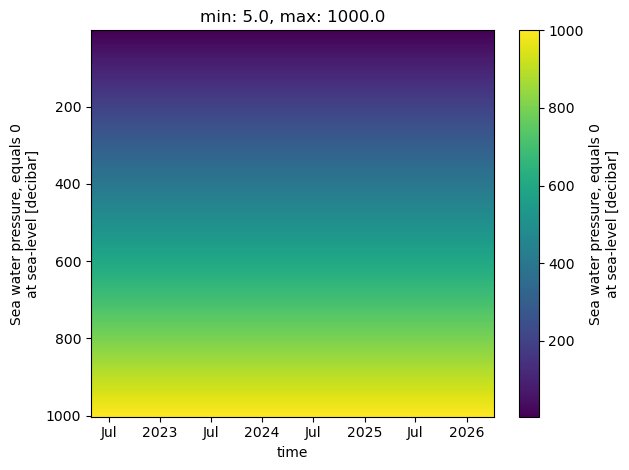

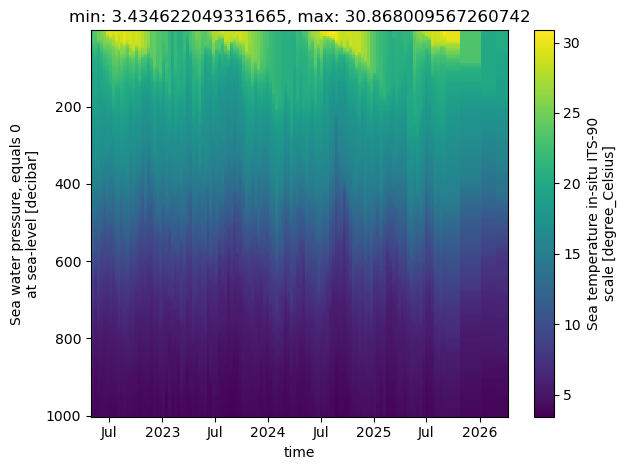

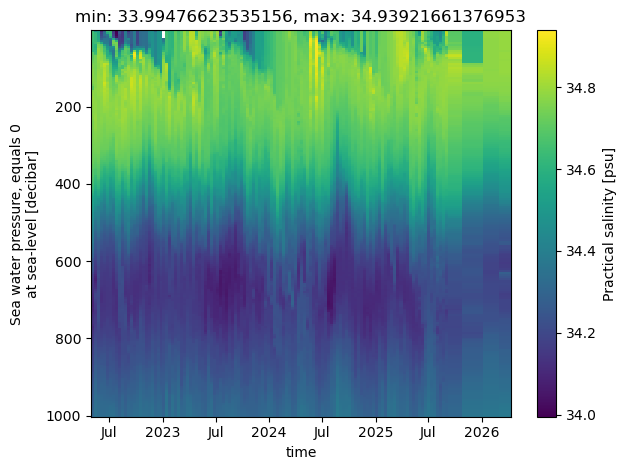

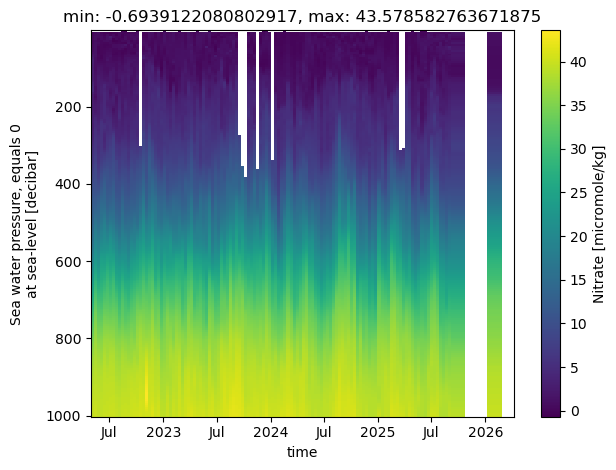

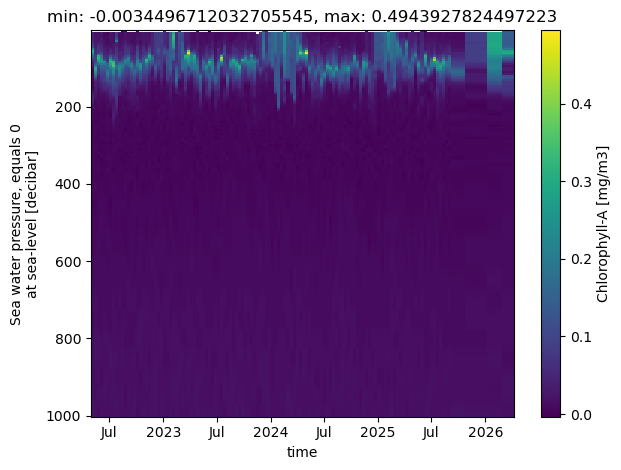

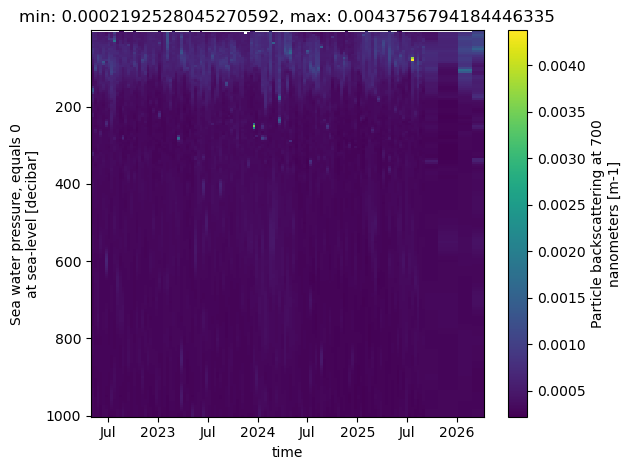

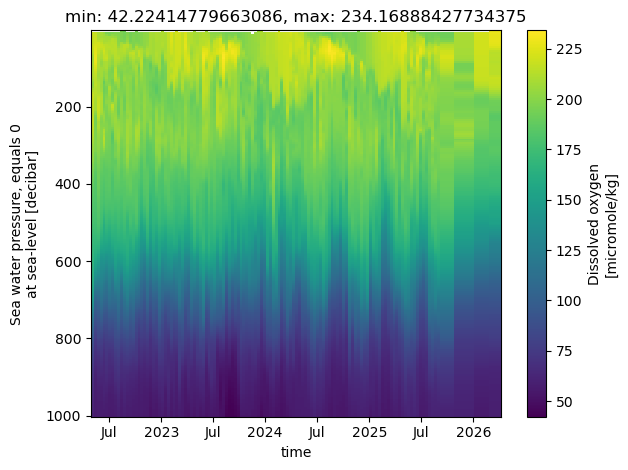

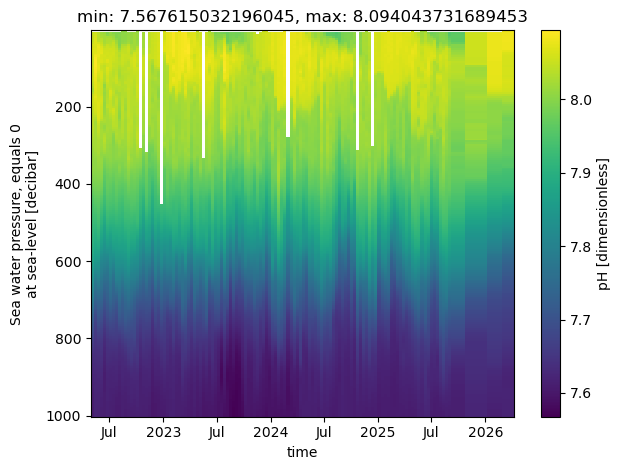

In [77]:
plt.close('all')

for i in range(len(var_list)):
    if var_list[i] in ds.data_vars:
        ds_interp = interp_and_update(filter_qc(ds,var_list[i],qc_list), ds['PRES_ADJUSTED'], ds_interp)

        # 2D heatmap
        da2plot = ds_interp[var_list[i]]
        plt.figure()
        mmin = da2plot.min().astype(float).values
        mmax = da2plot.max().astype(float).values
        da2plot.plot(x="time",vmin=mmin,vmax=mmax)
        plt.title(f"min: {mmin}, max: {mmax}")            
        plt.gca().invert_yaxis()
        plt.tight_layout()
        
    else:
        print(f'{var_list[i]} does not exist...')
ds_interp

In [74]:
plot_2d_heatmap(ds_interp,var_list,None)

No variable named PRES_ADJUSTED available
No variable named TEMP_ADJUSTED available
No variable named PSAL_ADJUSTED available
No variable named DOWNWELLING_PAR_ADJUSTED available
No variable named NITRATE_ADJUSTED available
No variable named CHLA_ADJUSTED available
No variable named BBP700_ADJUSTED available
No variable named DOXY_ADJUSTED available
No variable named PH_IN_SITU_TOTAL_ADJUSTED available


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

▶️ **Run** the cell below to use the function

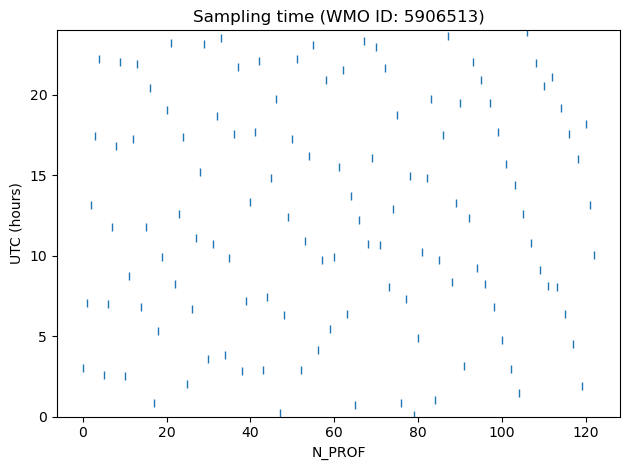

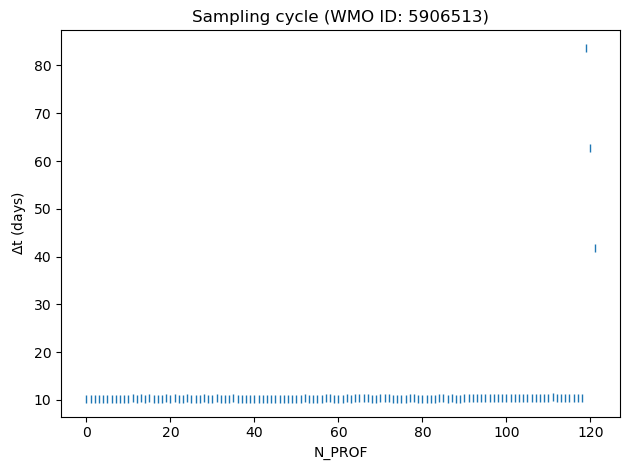

In [92]:


# offset each profile by the minimum value if it is negative; otherwise, do nothing.
# we assume that profiles are continuous (relative changes are real) and negative values are small
def offset_by_neg(da2d_in):
    return da2d_in - da2d_in.min("depth").clip(max=0)
# set the negatives to zeros for BBP.
# we assume that profiles are spiky and large negative values can exit even after QC filtering (so offset_by_neg is unsuitable).
def set_neg2zero(da2d_in):
    return da2d_in.clip(min=0)

Above, you should see two figures. The first one shows the time in which each profiling took place. The time is given in UTC. We can see that the sampling time for this float is well distributed. This is a standard practice for a float that wants to avoid the sampling bias due to sampling time.

The second figure shows the time difference between consecutive profiles. We see that the profiling was done pretty consistently at an interval of about 10 days (which is a standard frequency for Argo) until the last few cycles in which the intervals exceeded 40 days. For scientific analysis, we probably want to exclude these profiles due to inconsistent intervals.

### Define the function `filter_qc`

▶️ **Run** the cell below to define a function that filters the data by the QC flags.

### Define the function `plot_2d_heatmap`

We will next visualize the 2D arrays of the adjusted variables (pressure, temperature, salinity, and the six standard BGC parameters).

▶️ **Run** the cell below to define a function that attempts to plot 2D heatmap (pcolormesh) for each variable. It returns a text either if the variable is not available in the dataset or if all values are missing for that variable.

▶️ Run the cell below to define the variable list and then run the function to plot the RAW data

No variable named DOWNWELLING_PAR_ADJUSTED available


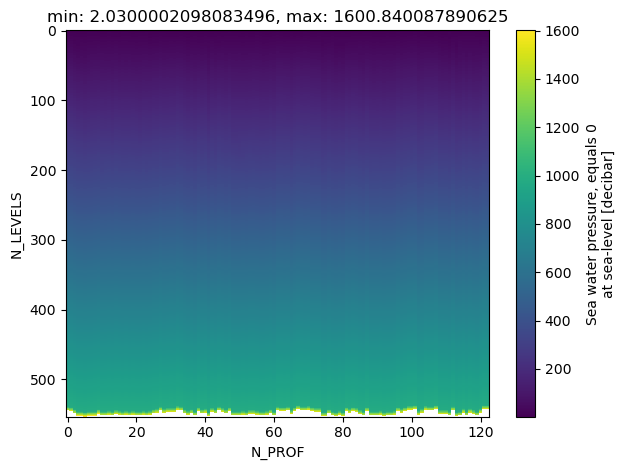

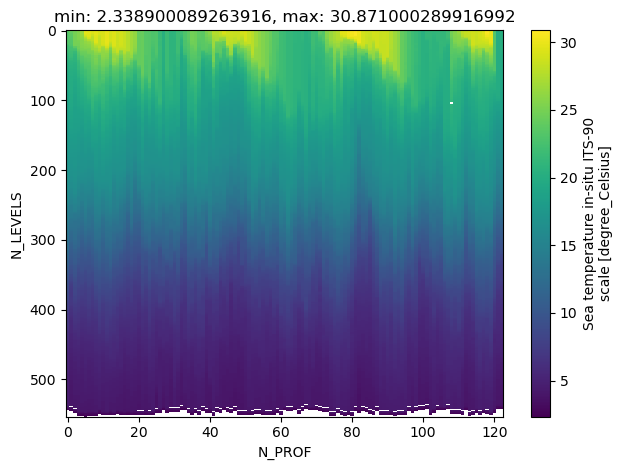

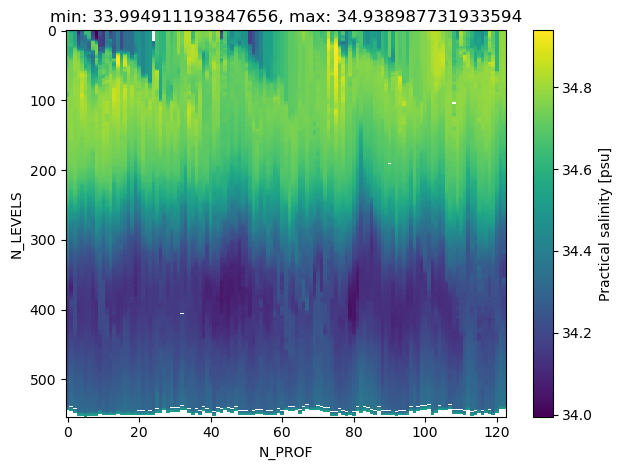

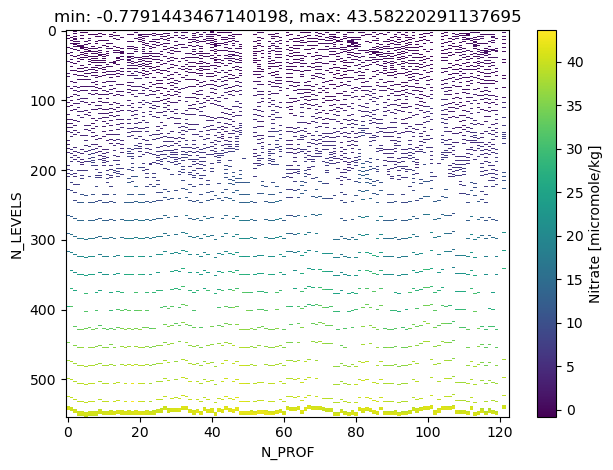

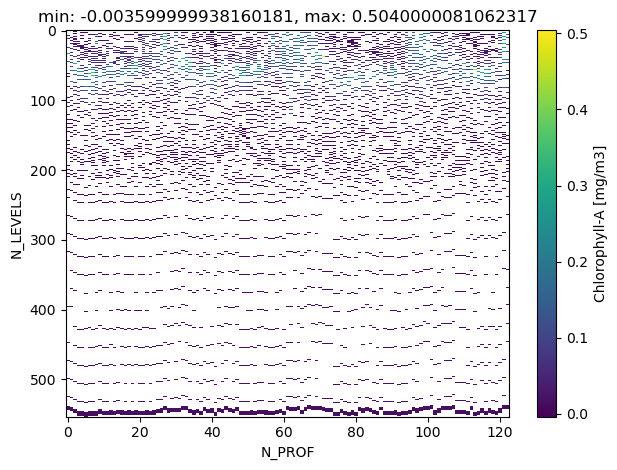

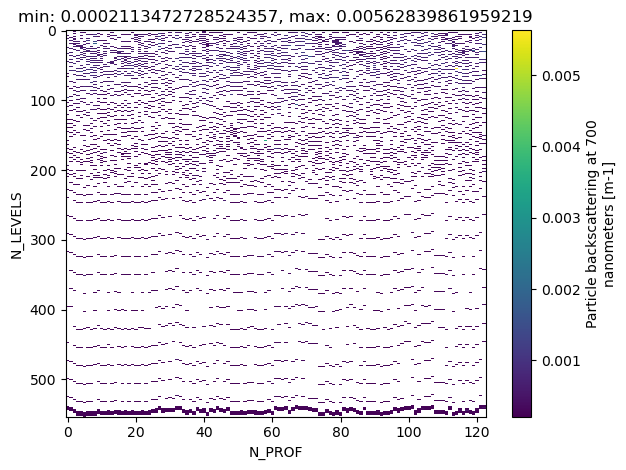

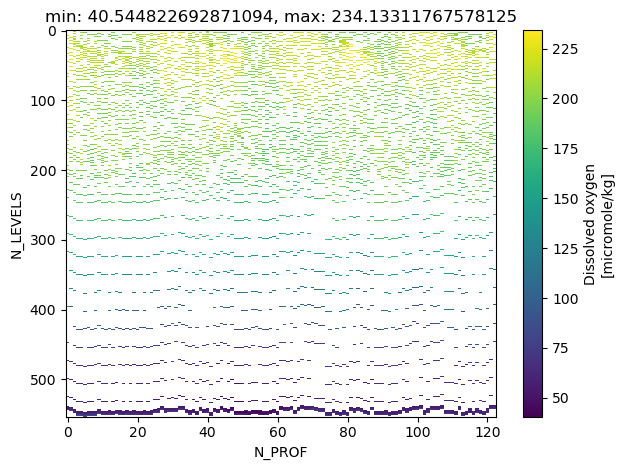

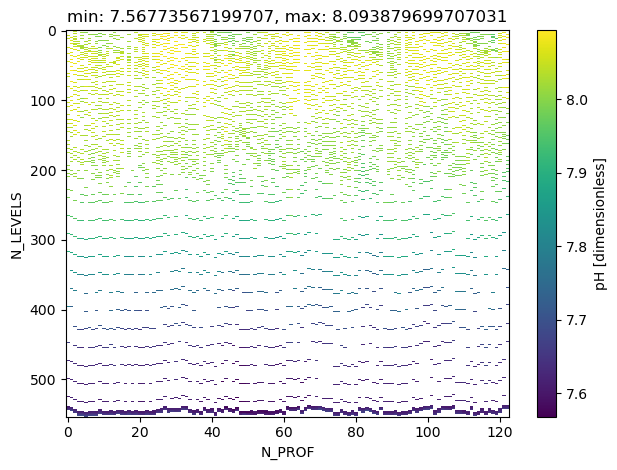

In [95]:
var_list = ['PRES_ADJUSTED',
            'TEMP_ADJUSTED',
            'PSAL_ADJUSTED',
            'DOWNWELLING_PAR_ADJUSTED',
            'NITRATE_ADJUSTED',
            'CHLA_ADJUSTED',
            'BBP700_ADJUSTED',
            'DOXY_ADJUSTED',
            'PH_IN_SITU_TOTAL_ADJUSTED',
           ]

plot_2d_heatmap(ds, var_list, qc_in=None)

Can you scroll down the heatmap above to see if you produced several heatmaps? From these heatmaps, we notice a few things:

* **PAR** is not available (as expected from the information extracted from the index file in Lesson 1).
* The vertical coverage is the upper 1,600 m (dbar).
* Compared to temperature and salinity, the vertical resolutions of the BGC parameters are coarse.
* **Nitrate** and **chlorophyll-a** have negative values. 

Above, we have plotted all adjusted values, but in practice, we need to filter out bad-quality values using QC flags.

▶️ **Run** the cell below to define the accepted QC flags (*1* for this example, which means *good*) and plot the heatmaps after applying the QC filter.

No variable named DOWNWELLING_PAR_ADJUSTED available


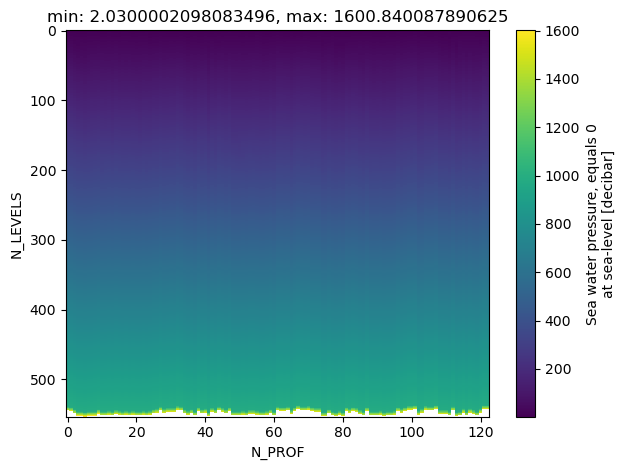

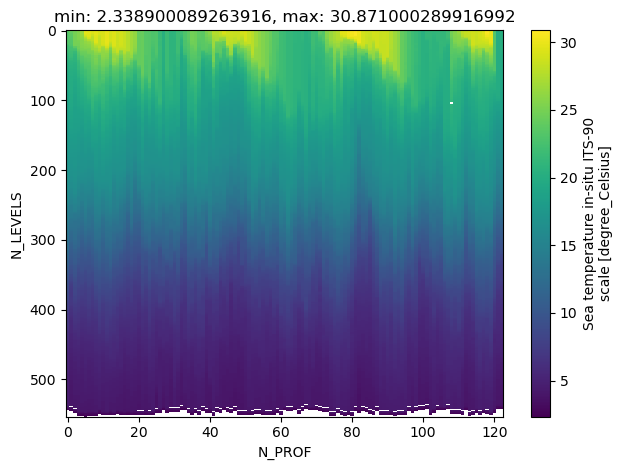

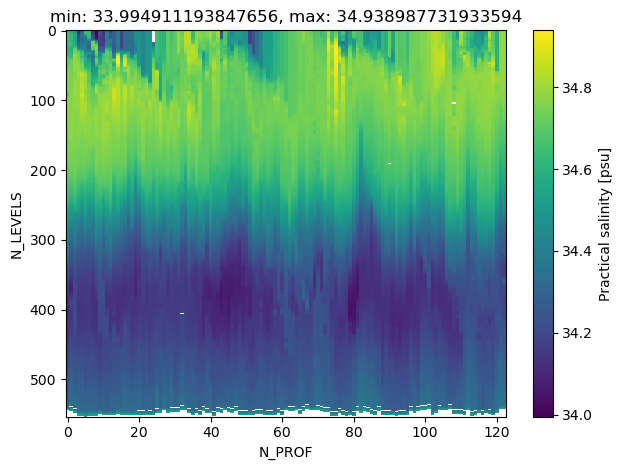

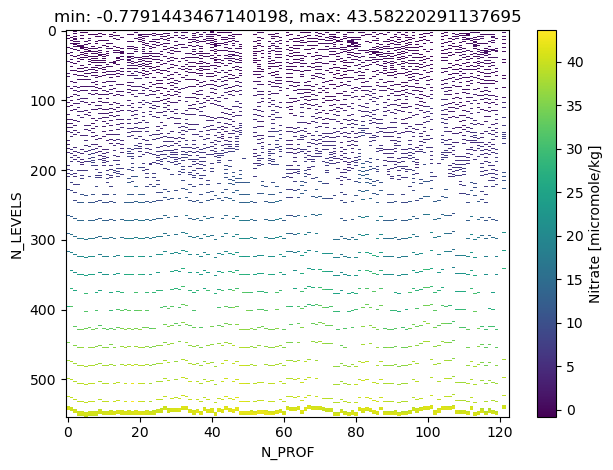

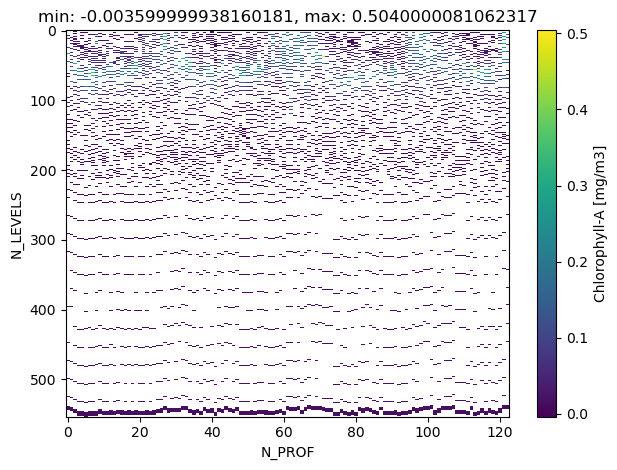

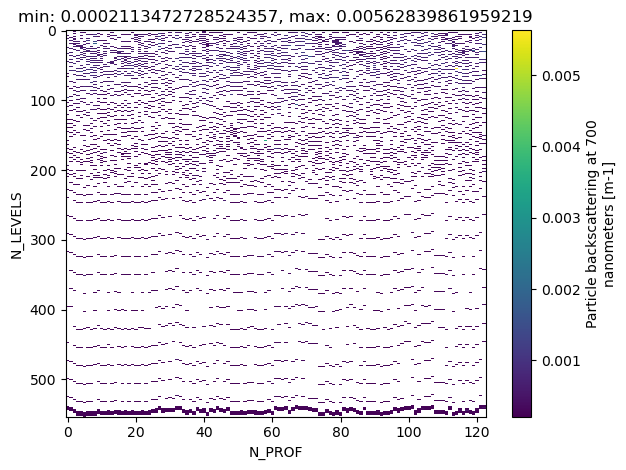

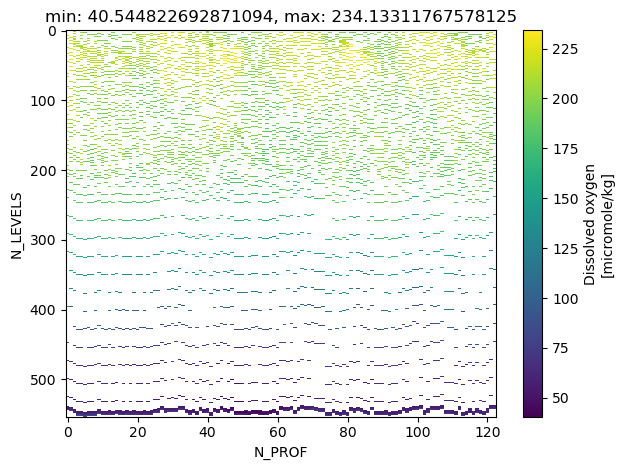

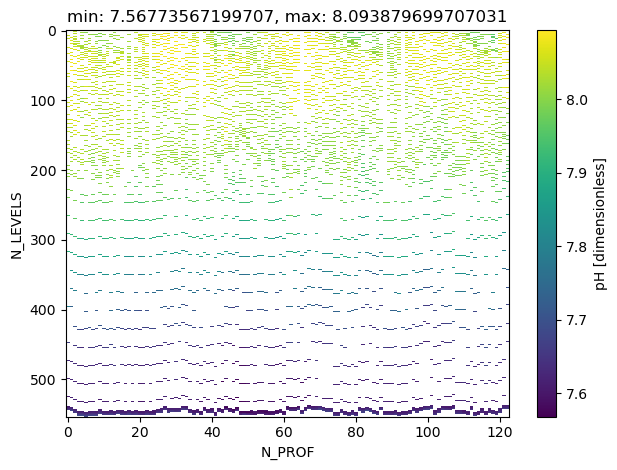

In [96]:
qc_list = [1,2,5,8]

plot_2d_heatmap(ds, var_list, qc_list)

By comparing with the heatmaps without the QC filter plotted previously, we can see that there is hardly any difference, meaning that this float time series are of good quality. In the exercises below, we will see cases where the QC filter helps to remove some *bad* profiles.

**This is the end of the tutorials for Lesson 4. Hope you enjoyed it!**

---

## 📝 Exercises

### Exercise 1: Visualize the float time series downloaded in Ex 2 of Lesson 3 (i.e., WMO ID = 5905531) following the steps below:

* Open the dataset with `xr.open_dataset`.
* Visualize the time and frequency of the profiling using `time_and_dt`.
* Visualize the standard variables (defined as `var_list` above) using `plot_2d_heatmap` without the QC filter.

**On a separate cell:**

* Visualize the standard variables with the standard QC filter (i.e., 1,2,5,8). Compare the heatmaps with those without the QC filter.

No VALID value available from DOWNWELLING_PAR_ADJUSTED


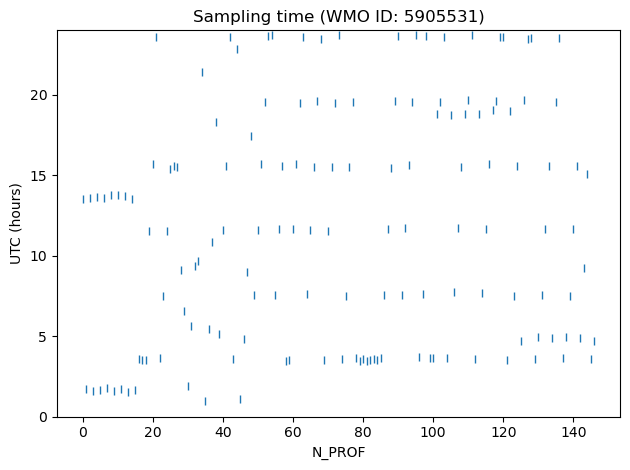

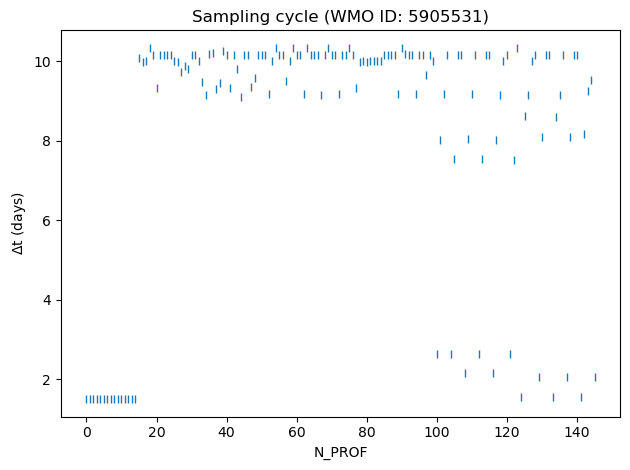

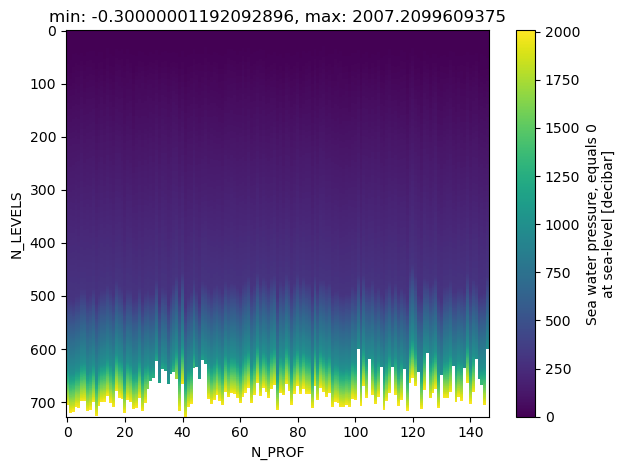

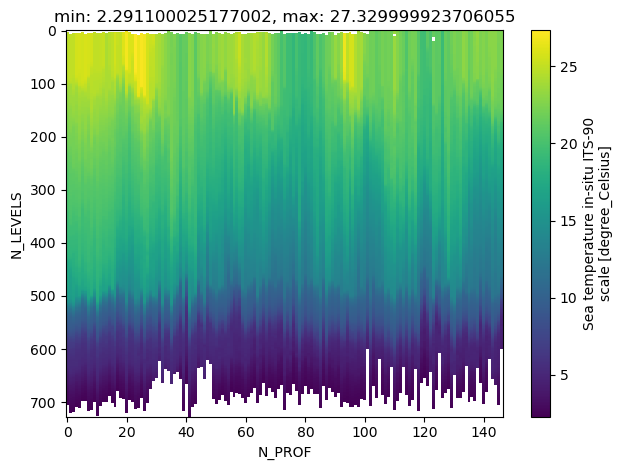

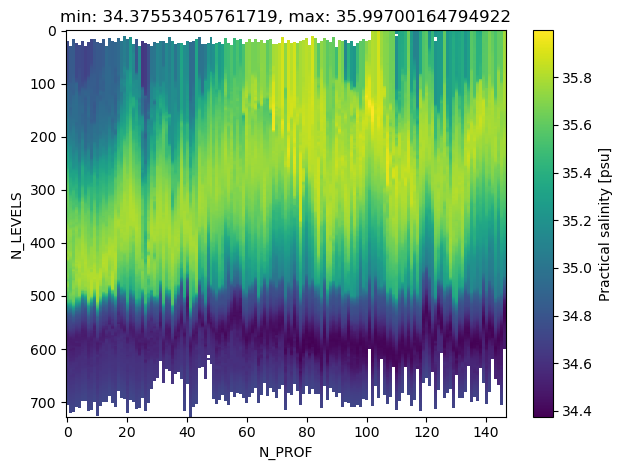

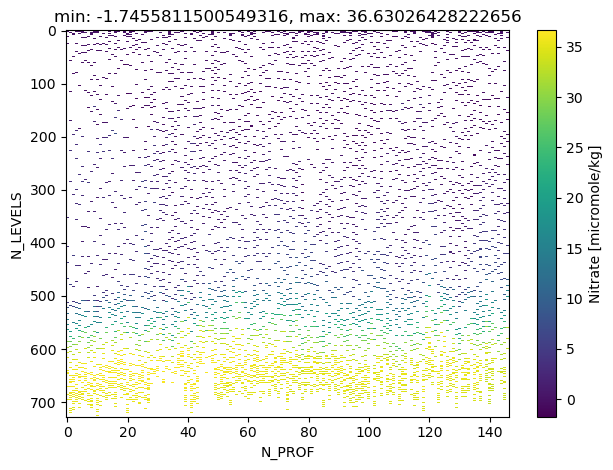

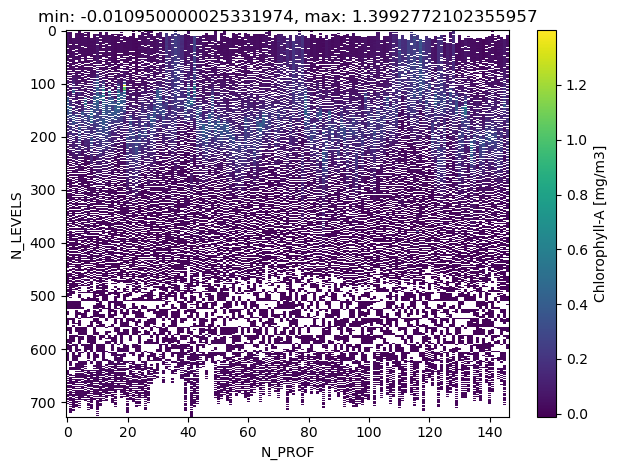

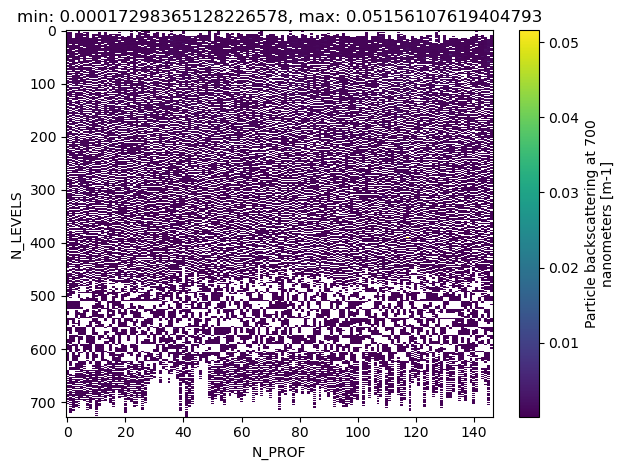

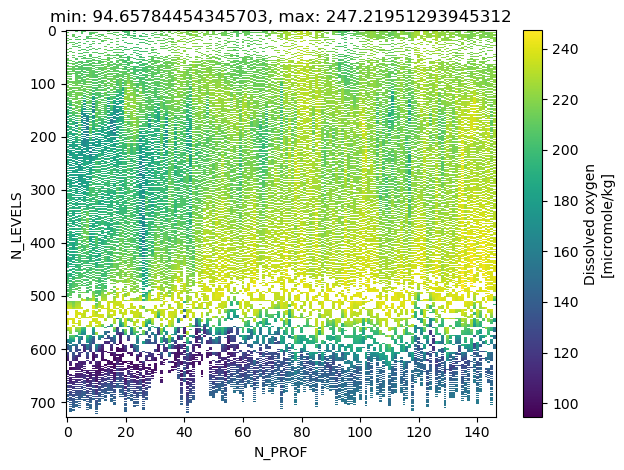

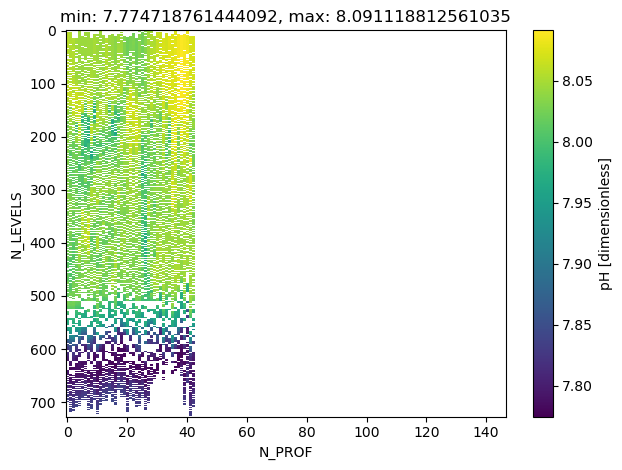

In [81]:
wmoid = 5905531
in_file = f"../floats/{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 

plt.close('all')

time_and_dt(ds)

plot_2d_heatmap(ds, var_list, qc_in=None)

No variable named DOWNWELLING_PAR_ADJUSTED available


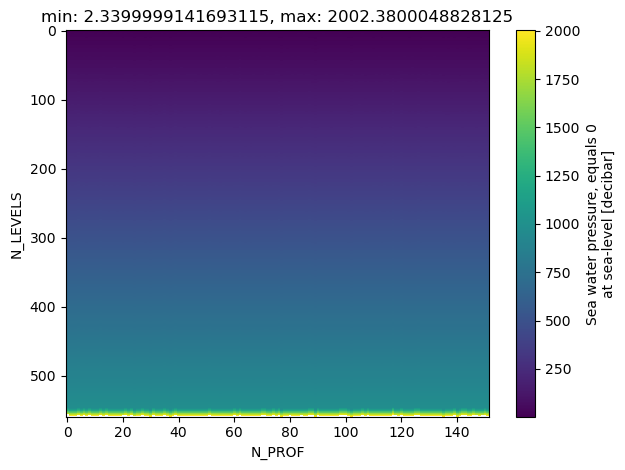

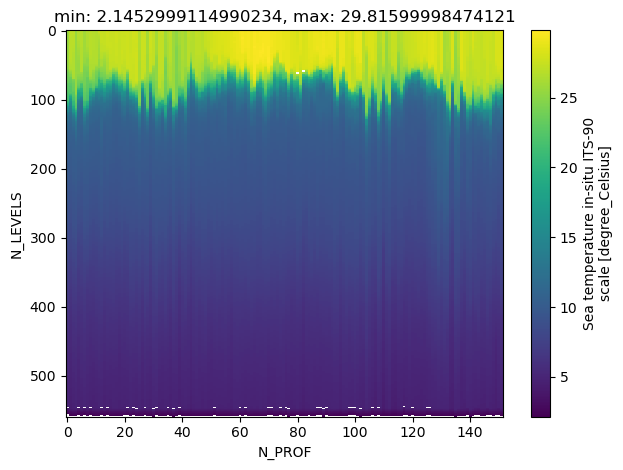

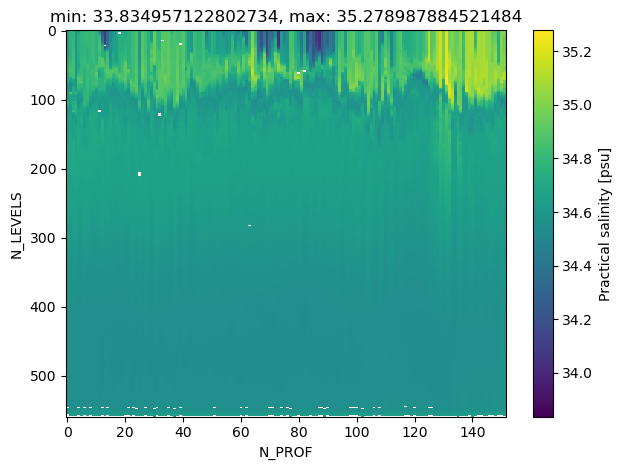

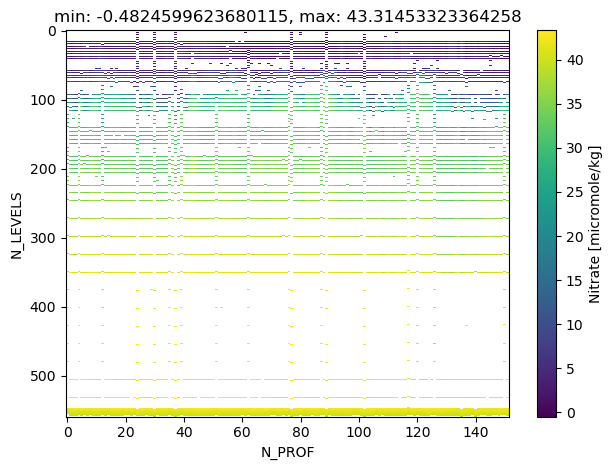

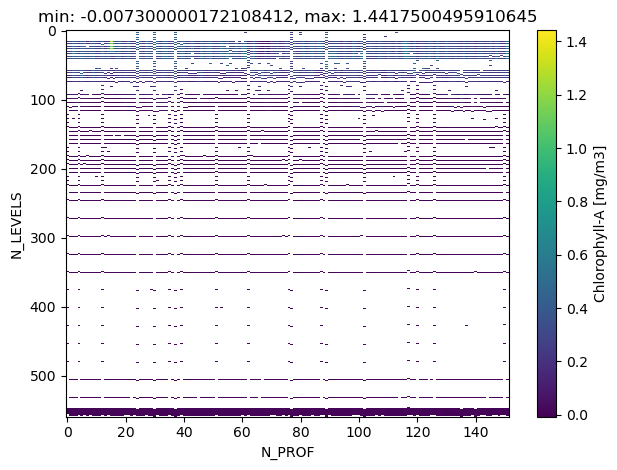

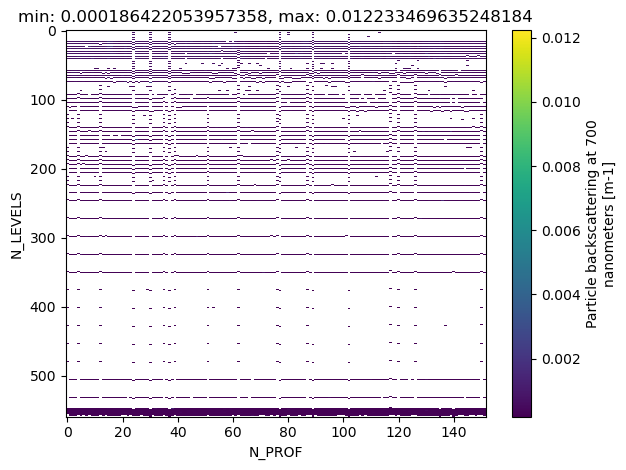

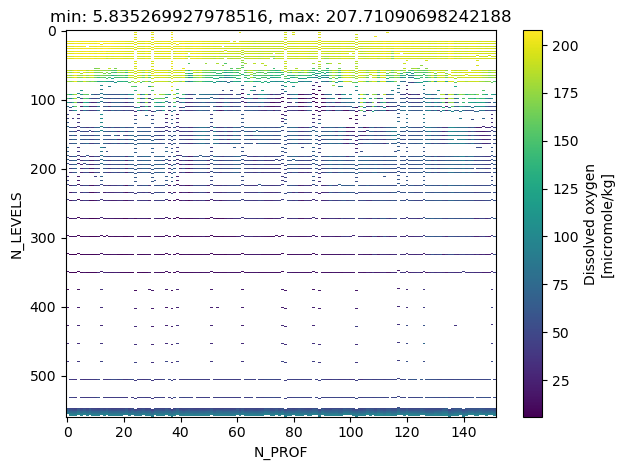

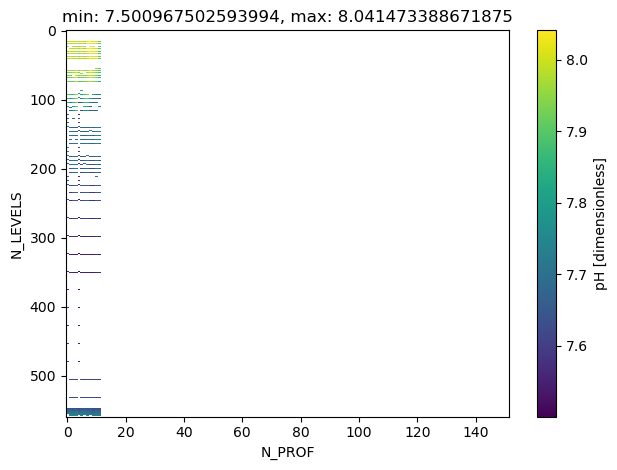

In [88]:
plot_2d_heatmap(ds, var_list, qc_in=[1,2,5,8])

### Exercise 2: Repeat the steps in Ex 1 but for the float WMO ID = 5906475

No variable named DOWNWELLING_PAR_ADJUSTED available


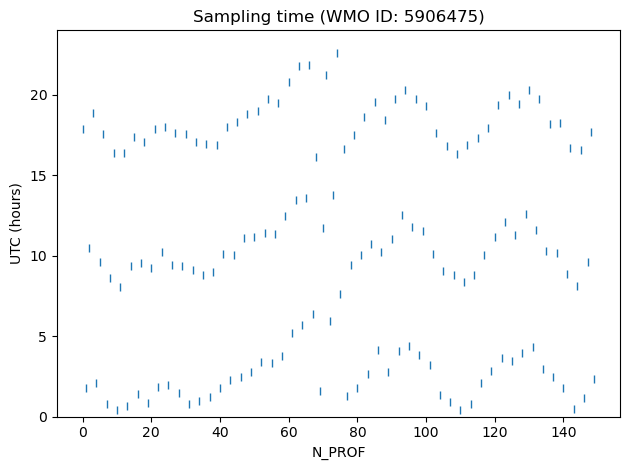

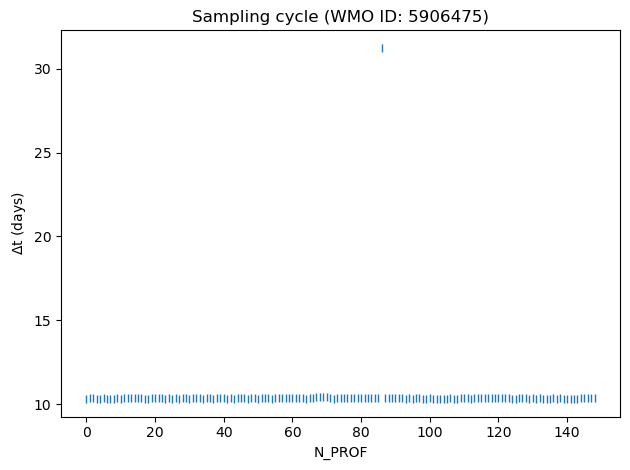

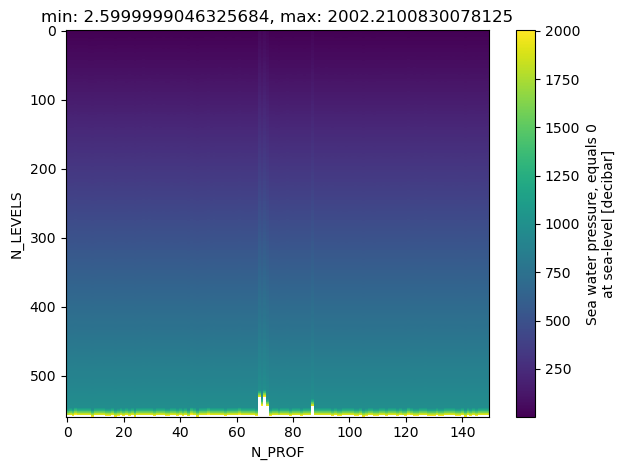

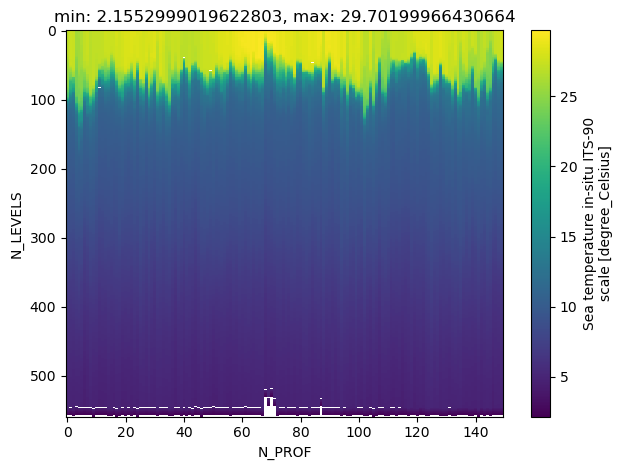

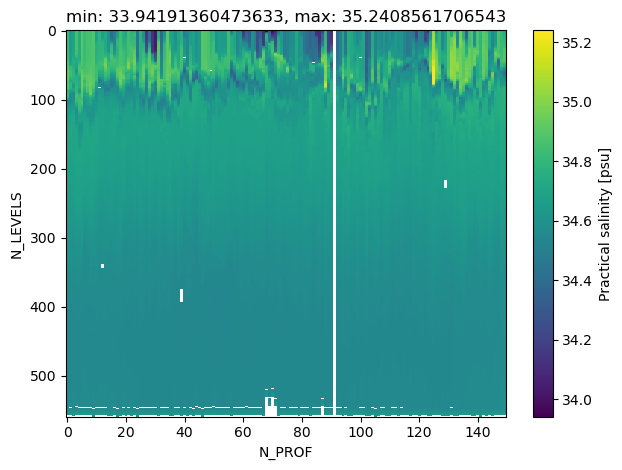

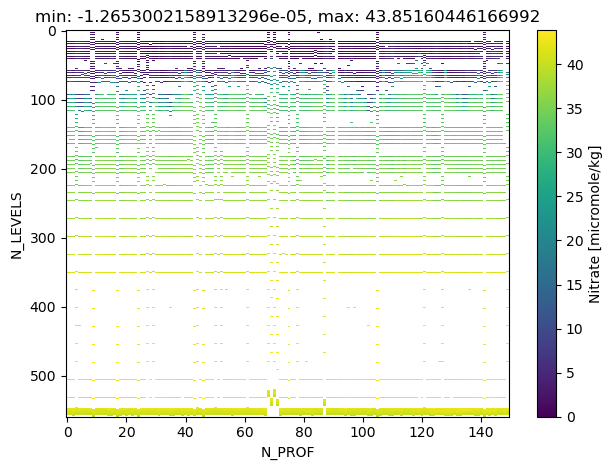

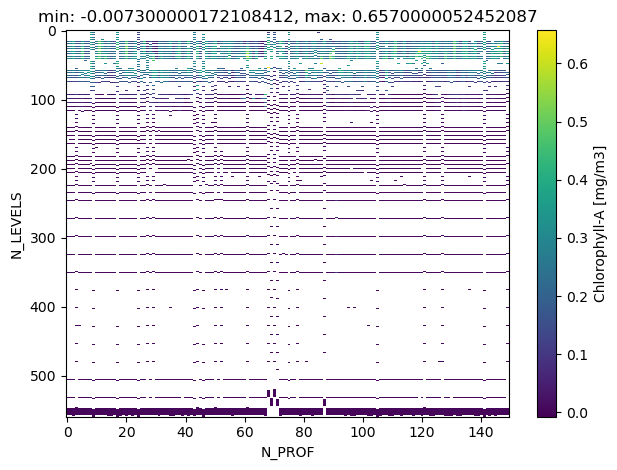

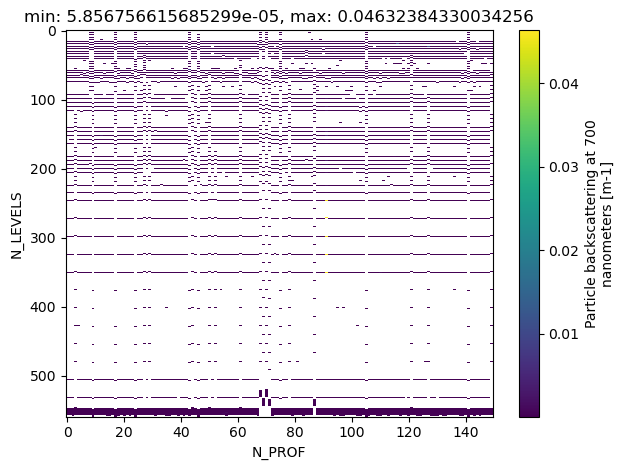

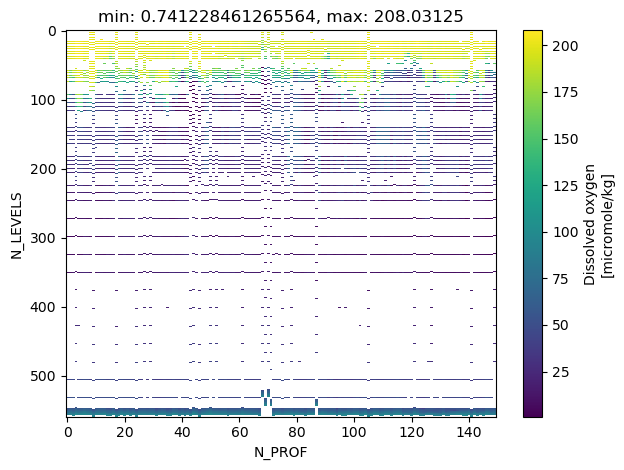

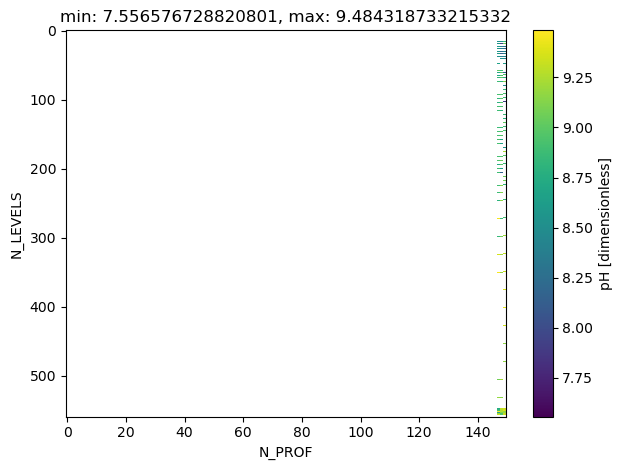

In [84]:
wmoid = 5906475
in_file = f"../floats/{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 

plt.close('all')

time_and_dt(ds)

plot_2d_heatmap(ds, var_list, qc_in=None)

No variable named DOWNWELLING_PAR_ADJUSTED available
No VALID value available from PH_IN_SITU_TOTAL_ADJUSTED


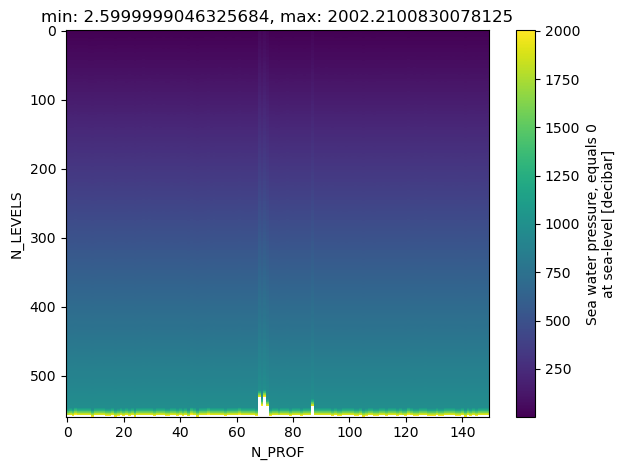

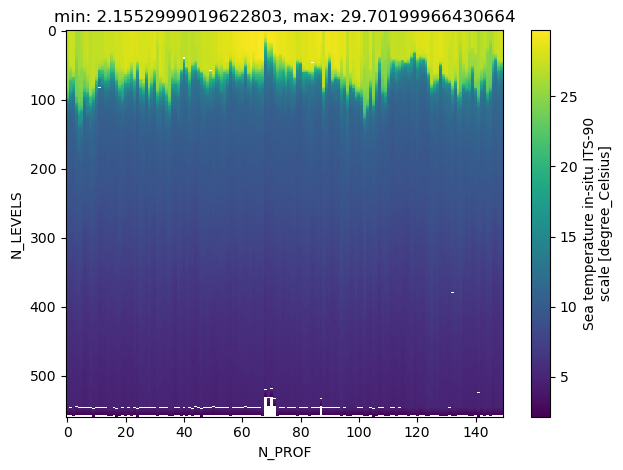

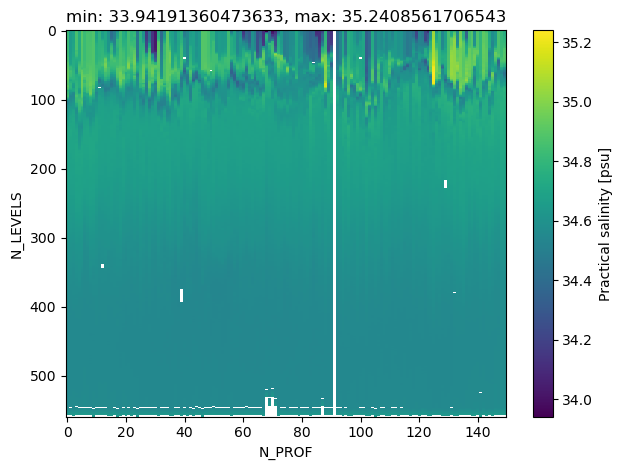

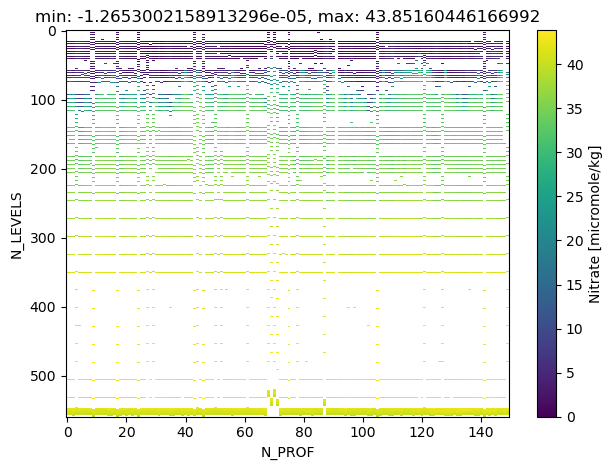

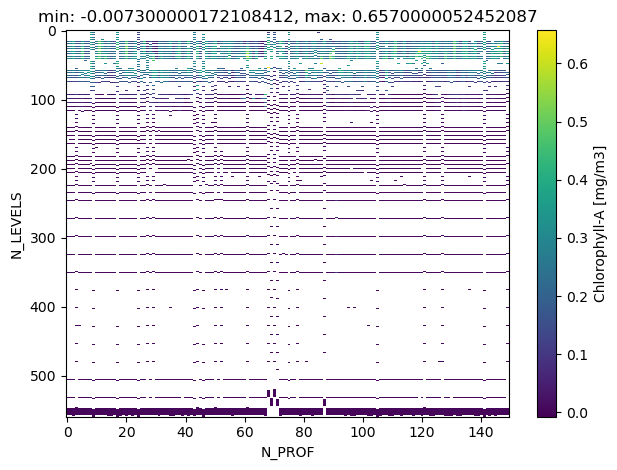

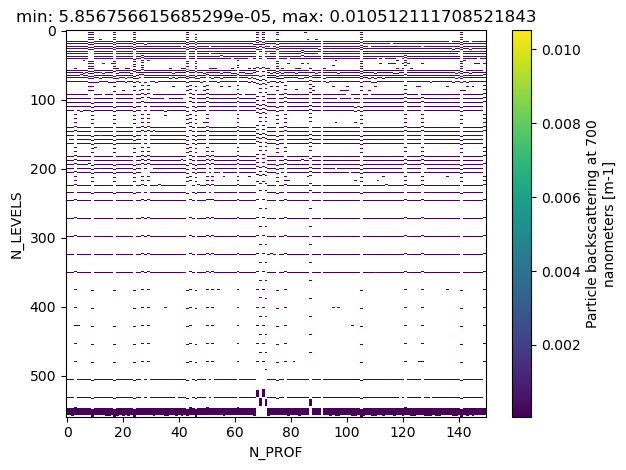

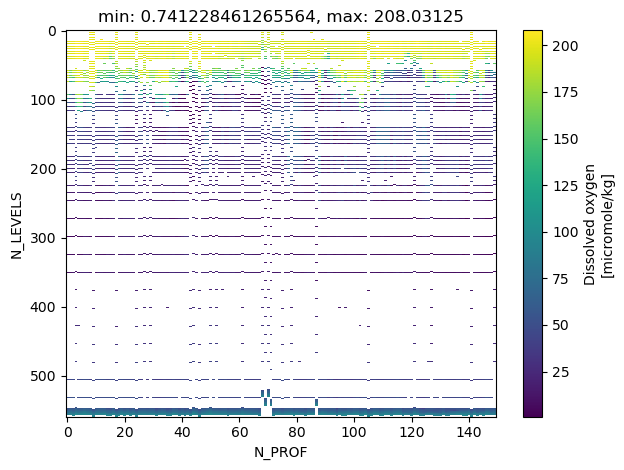

In [85]:
plot_2d_heatmap(ds, var_list, qc_in=[1,2,5,8])

### Exercise 3: Repeat the steps above but for the float WMO ID = 5906476

No variable named DOWNWELLING_PAR_ADJUSTED available


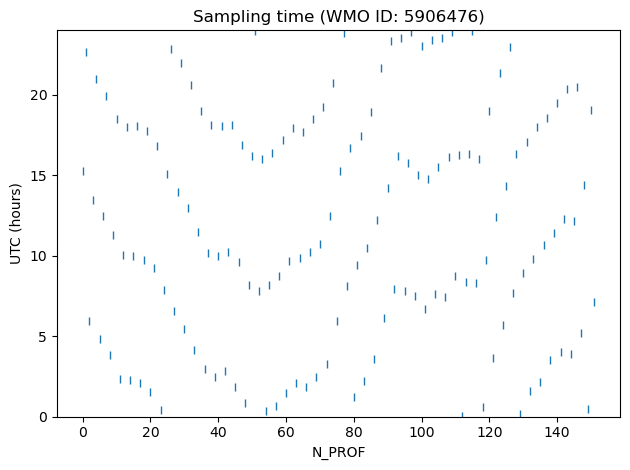

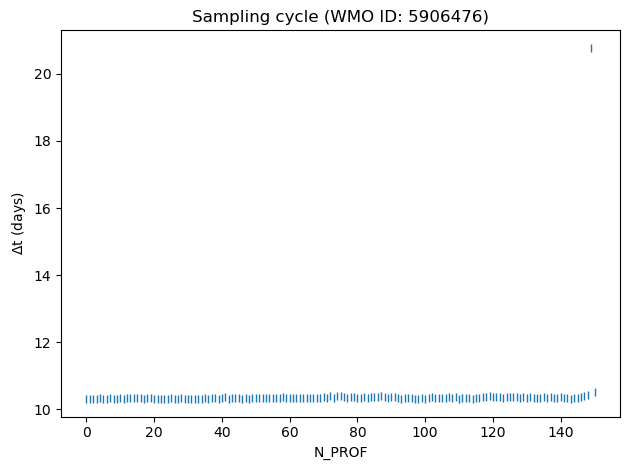

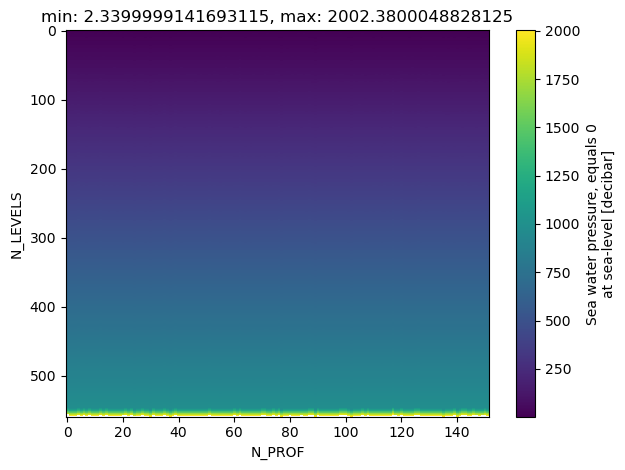

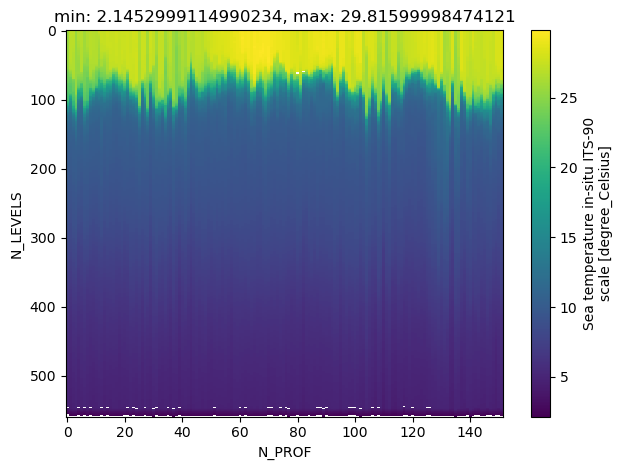

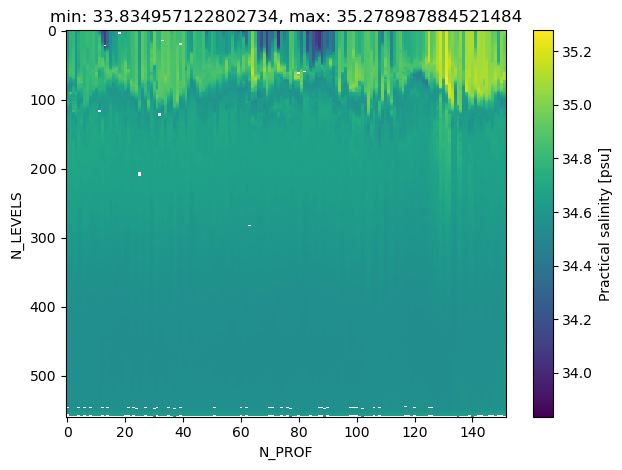

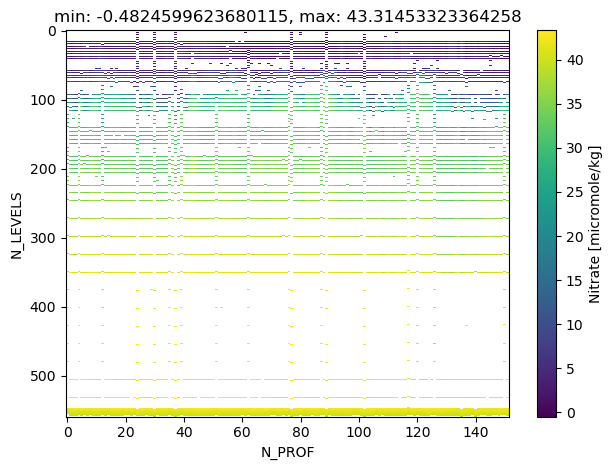

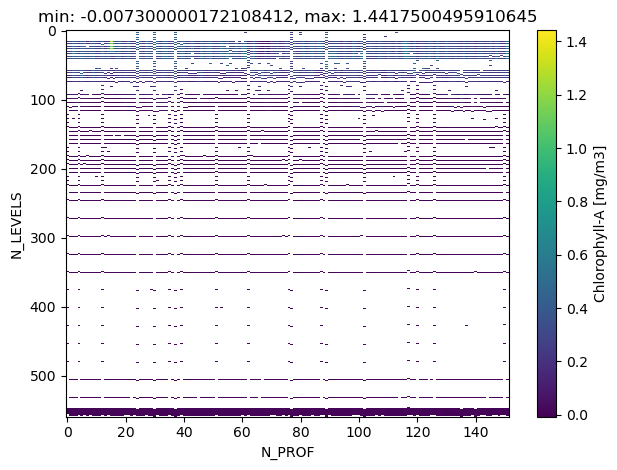

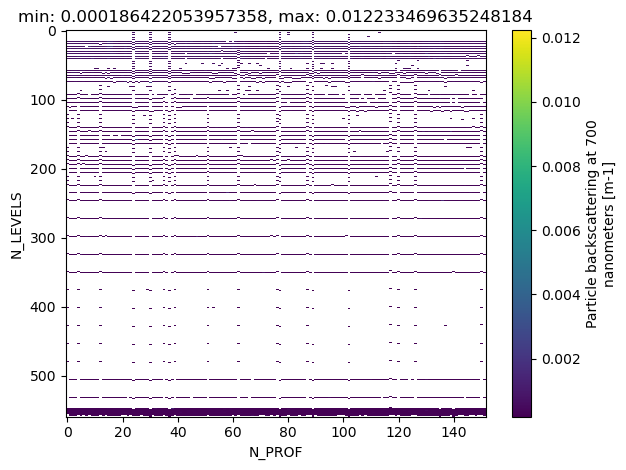

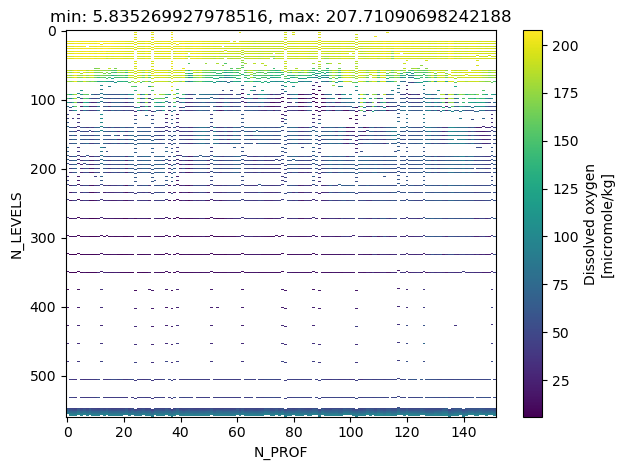

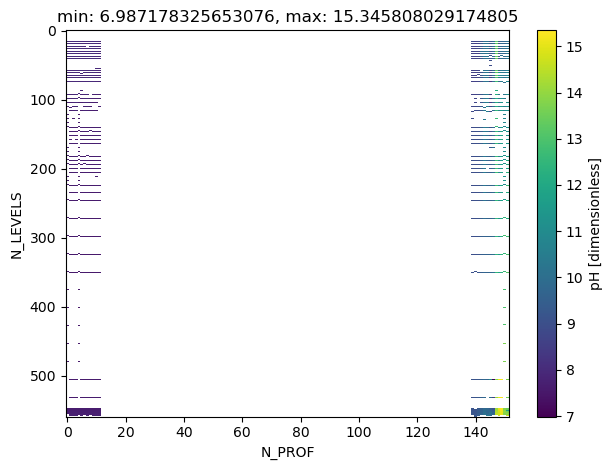

In [86]:
wmoid = 5906476
in_file = f"../floats/{wmoid}/{wmoid}_Sprof.nc"
ds = xr.open_dataset(in_file) 

plt.close('all')

time_and_dt(ds)

plot_2d_heatmap(ds, var_list, qc_in=None)

No variable named DOWNWELLING_PAR_ADJUSTED available


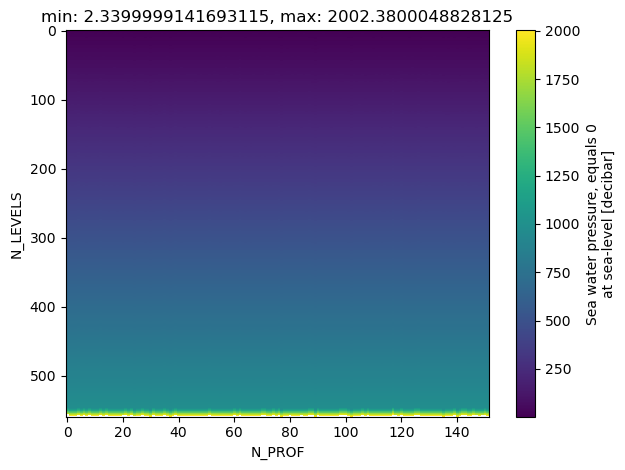

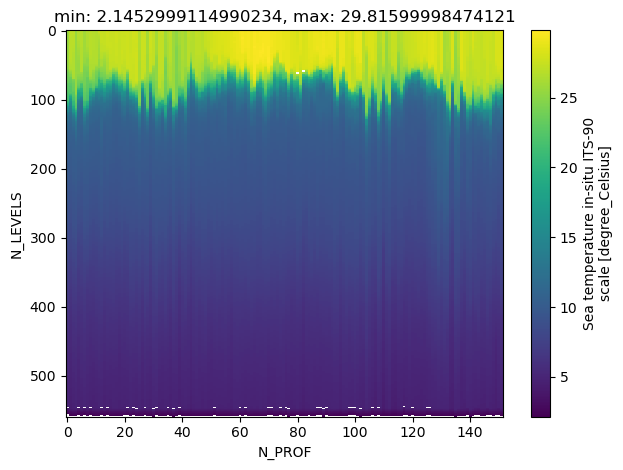

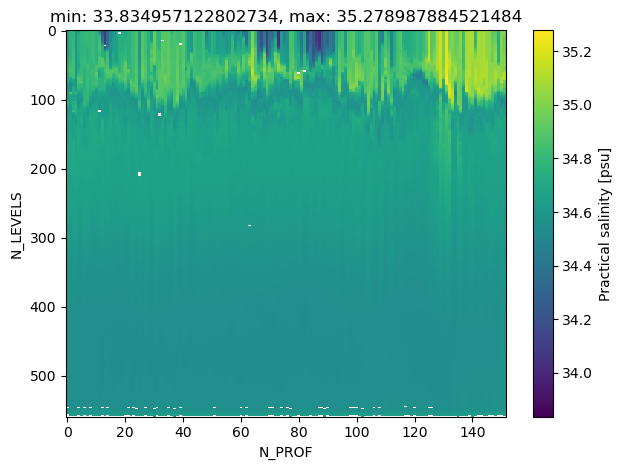

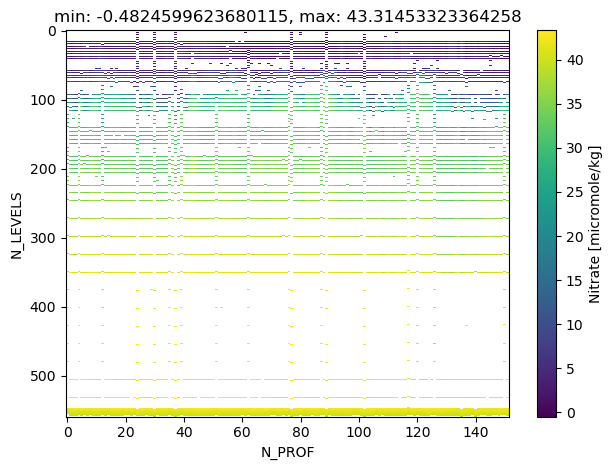

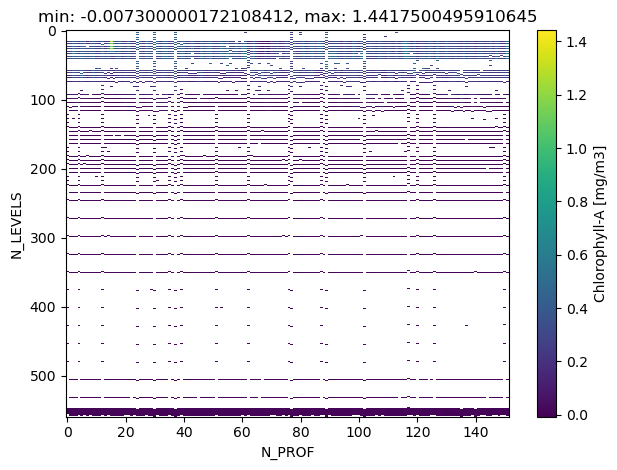

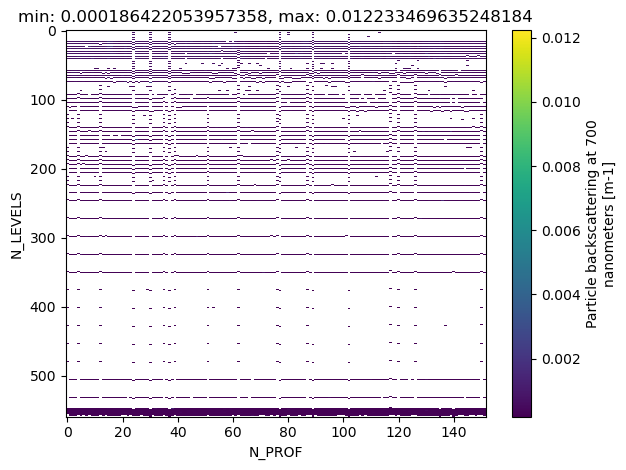

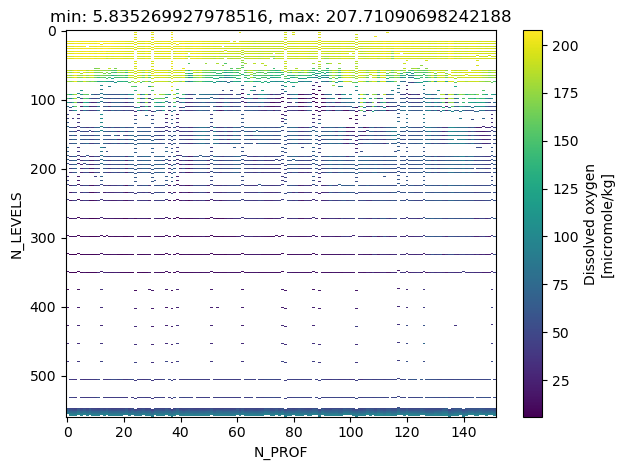

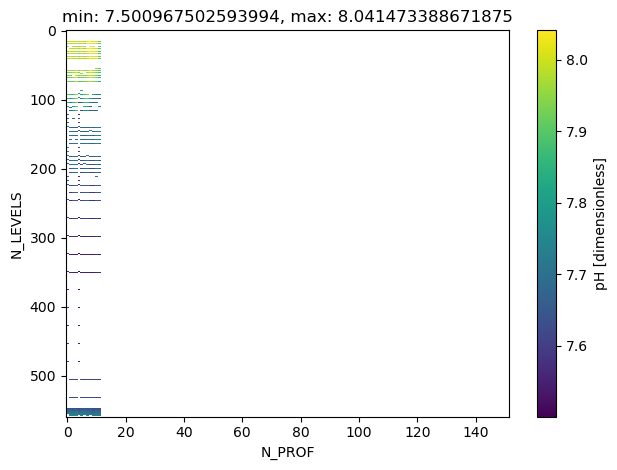

In [87]:
plot_2d_heatmap(ds, var_list, qc_in=[1,2,5,8])


---

This is the end of the lesson. If you are using **Binder**, don't forget to dowload the files created in this lesson before you lose connection!

Well done 🎉 Take a break 💤, have another cup ☕, and move to the next lesson ✍️ when you are ready 💪

While your memory is fresh, please feel free to provide your user experience on this lesson by visiting [this link](https://forms.gle/oAGmz5RTW4Pp46bt7). Thanks!